# 📈 **Regresión Lineal**

### Actividad con Scikit-learn
### Versión Adaptada: Dr. Hugo García Tecocoatzi

**En Machine Learning y en este notebook vamos a usar Scikit-learn**

<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/download_(1)_slz6.png" border="0" alt="آپلود عکس" /></a>

### **¿Para qué se usa scikit-learn?**

Scikit-learn (Sklearn) es la biblioteca más útil y robusta para machine learning en Python. Proporciona una selección de herramientas eficientes para machine learning y modelado estadístico que incluyen clasificación, regresión, agrupamiento y reducción de dimensionalidad a través de una interfaz consistente en Python.

En esta ocasión lo usaremos para entrenar un modelo de regresión lineal


#### **¿Para qué se usa la regresión lineal?**

El análisis de regresión lineal se usa para predecir el valor de una variable basándose en el valor de otra variable. La variable que deseas predecir se llama variable dependiente. La variable que usas para predecir el valor de la otra variable se llama variable independiente (predictora).

# **Haciendo predicciones con una Regresión Lineal**

Dado que la representación es una ecuación lineal, hacer predicciones es tan simple como resolver la ecuación para un conjunto específico de entradas.

Vamos a hacer esto concreto con un ejemplo. Imagina que estamos prediciendo el peso (y) a partir de la altura (x). Nuestra representación del modelo de regresión lineal para este problema sería:

**y = B0 + B1 * x1**

o

**peso = B0 + B1 * altura**

Donde B0 es el coeficiente de sesgo y B1 es una razón que relaciona el peso y la altura. Usamos una técnica de machine learning para encontrar un buen conjunto de valores de coeficientes. Una vez encontrados, podemos introducir diferentes valores de altura para predecir el peso.

Por ejemplo, usemos B0 = 0.1 y B1 = 0.5. Vamos a introducirlos y calcular el peso (en kilogramos) para una persona con una altura de 182 centímetros.

peso = 0.1 + 0.5 * 182

peso = 91.1

Puedes ver que la ecuación anterior podría representarse como una línea en dos dimensiones. B0 es nuestro punto de partida independientemente de la altura que tengamos. Podemos recorrer un montón de alturas de 100 a 250 centímetros e introducirlas en la ecuación y obtener valores de peso, creando nuestra línea.

<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/sample-height-vs-weight-linear-regression_10h7.png" border="0" alt="آپلود عکس" /></a>

Ahora que sabemos cómo hacer predicciones dado un modelo de regresión lineal aprendido, veamos algunas reglas generales para preparar nuestros datos y aprovechar al máximo este tipo de modelo.

## 📤 Importar e Instalar Bibliotecas

In [2]:
pip install hvplot

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached idna-3.19-py3-none-any.whl.metadata (9.2 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
   ---------------------------------------- 0.0/6.0 MB ? eta -:--:--
   -------------------- ------------------- 3.1/6.0 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 6.0/6.0 MB 19.3 MB/s  0:00:00
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl (15 kB)
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   ------- -------------------------------- 5.8/30.3 MB 28.9 MB/s eta 0:00:01
   --------------- ------------------------ 11.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

from sklearn.model_selection import train_test_split

from sklearn import metrics

from sklearn.linear_model import LinearRegression

%matplotlib inline

### 💾 Explorar los Datos

In [4]:
df=pd.read_csv('Realestate.csv')

In [5]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


Tenemos los precios en dólar  por unidad de área de casas en  Real Estate. 

In [6]:
df.shape

(414, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [8]:
df.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


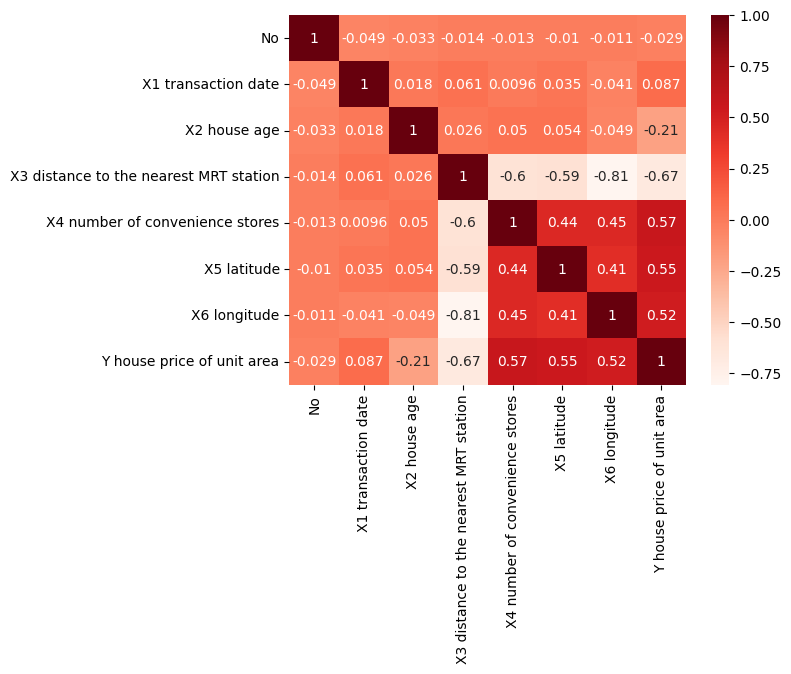

In [9]:
sns.heatmap(df.corr(), annot=True,cmap='Reds')
plt.show()

1. Describe qué información lees de esto.
Gracias a estas últimas líneas de código se pueden analizar las correlaciones entre las variables de la base de datos, específicamente, encuentro más útil el último mapa que representa  matriz de correlaciones entre las variables, ya que es mucho más atractiva visualmente y más fácil de  interpretar por ende. 

2. ¿Cuáles son las variables fuertemente correlacionadas? 
las más fuertes son: 
a. la longitud y la distancia a la estación de MRT más cercana tienen una correlaciónn negativa fuerte (-0.81)
b. el precio por unidad y la distancia a la estación de MRT más cercana también tienen una correlación negativa fuerte (-0.67)
c. la latitud y la distancia a la estación de MRT más cercana (-0.59)
d. el número de tiendas de conveniencia y la distancia a la estación de MRT más cercana (-0.6)
e. número de tiendas de conveniencia y el precio por unidad de área (0.57)
f. latitud/longitud  y precio por unidad de área (0.55 y 0.52 respectivamente)


3. ¿Te hacen sentido?
las que si me hacen sentido: f, e, d y b 
las que no me hacen tanto sentido: a y c 


### 📊 Análisis Exploratorio de Datos (EDA)

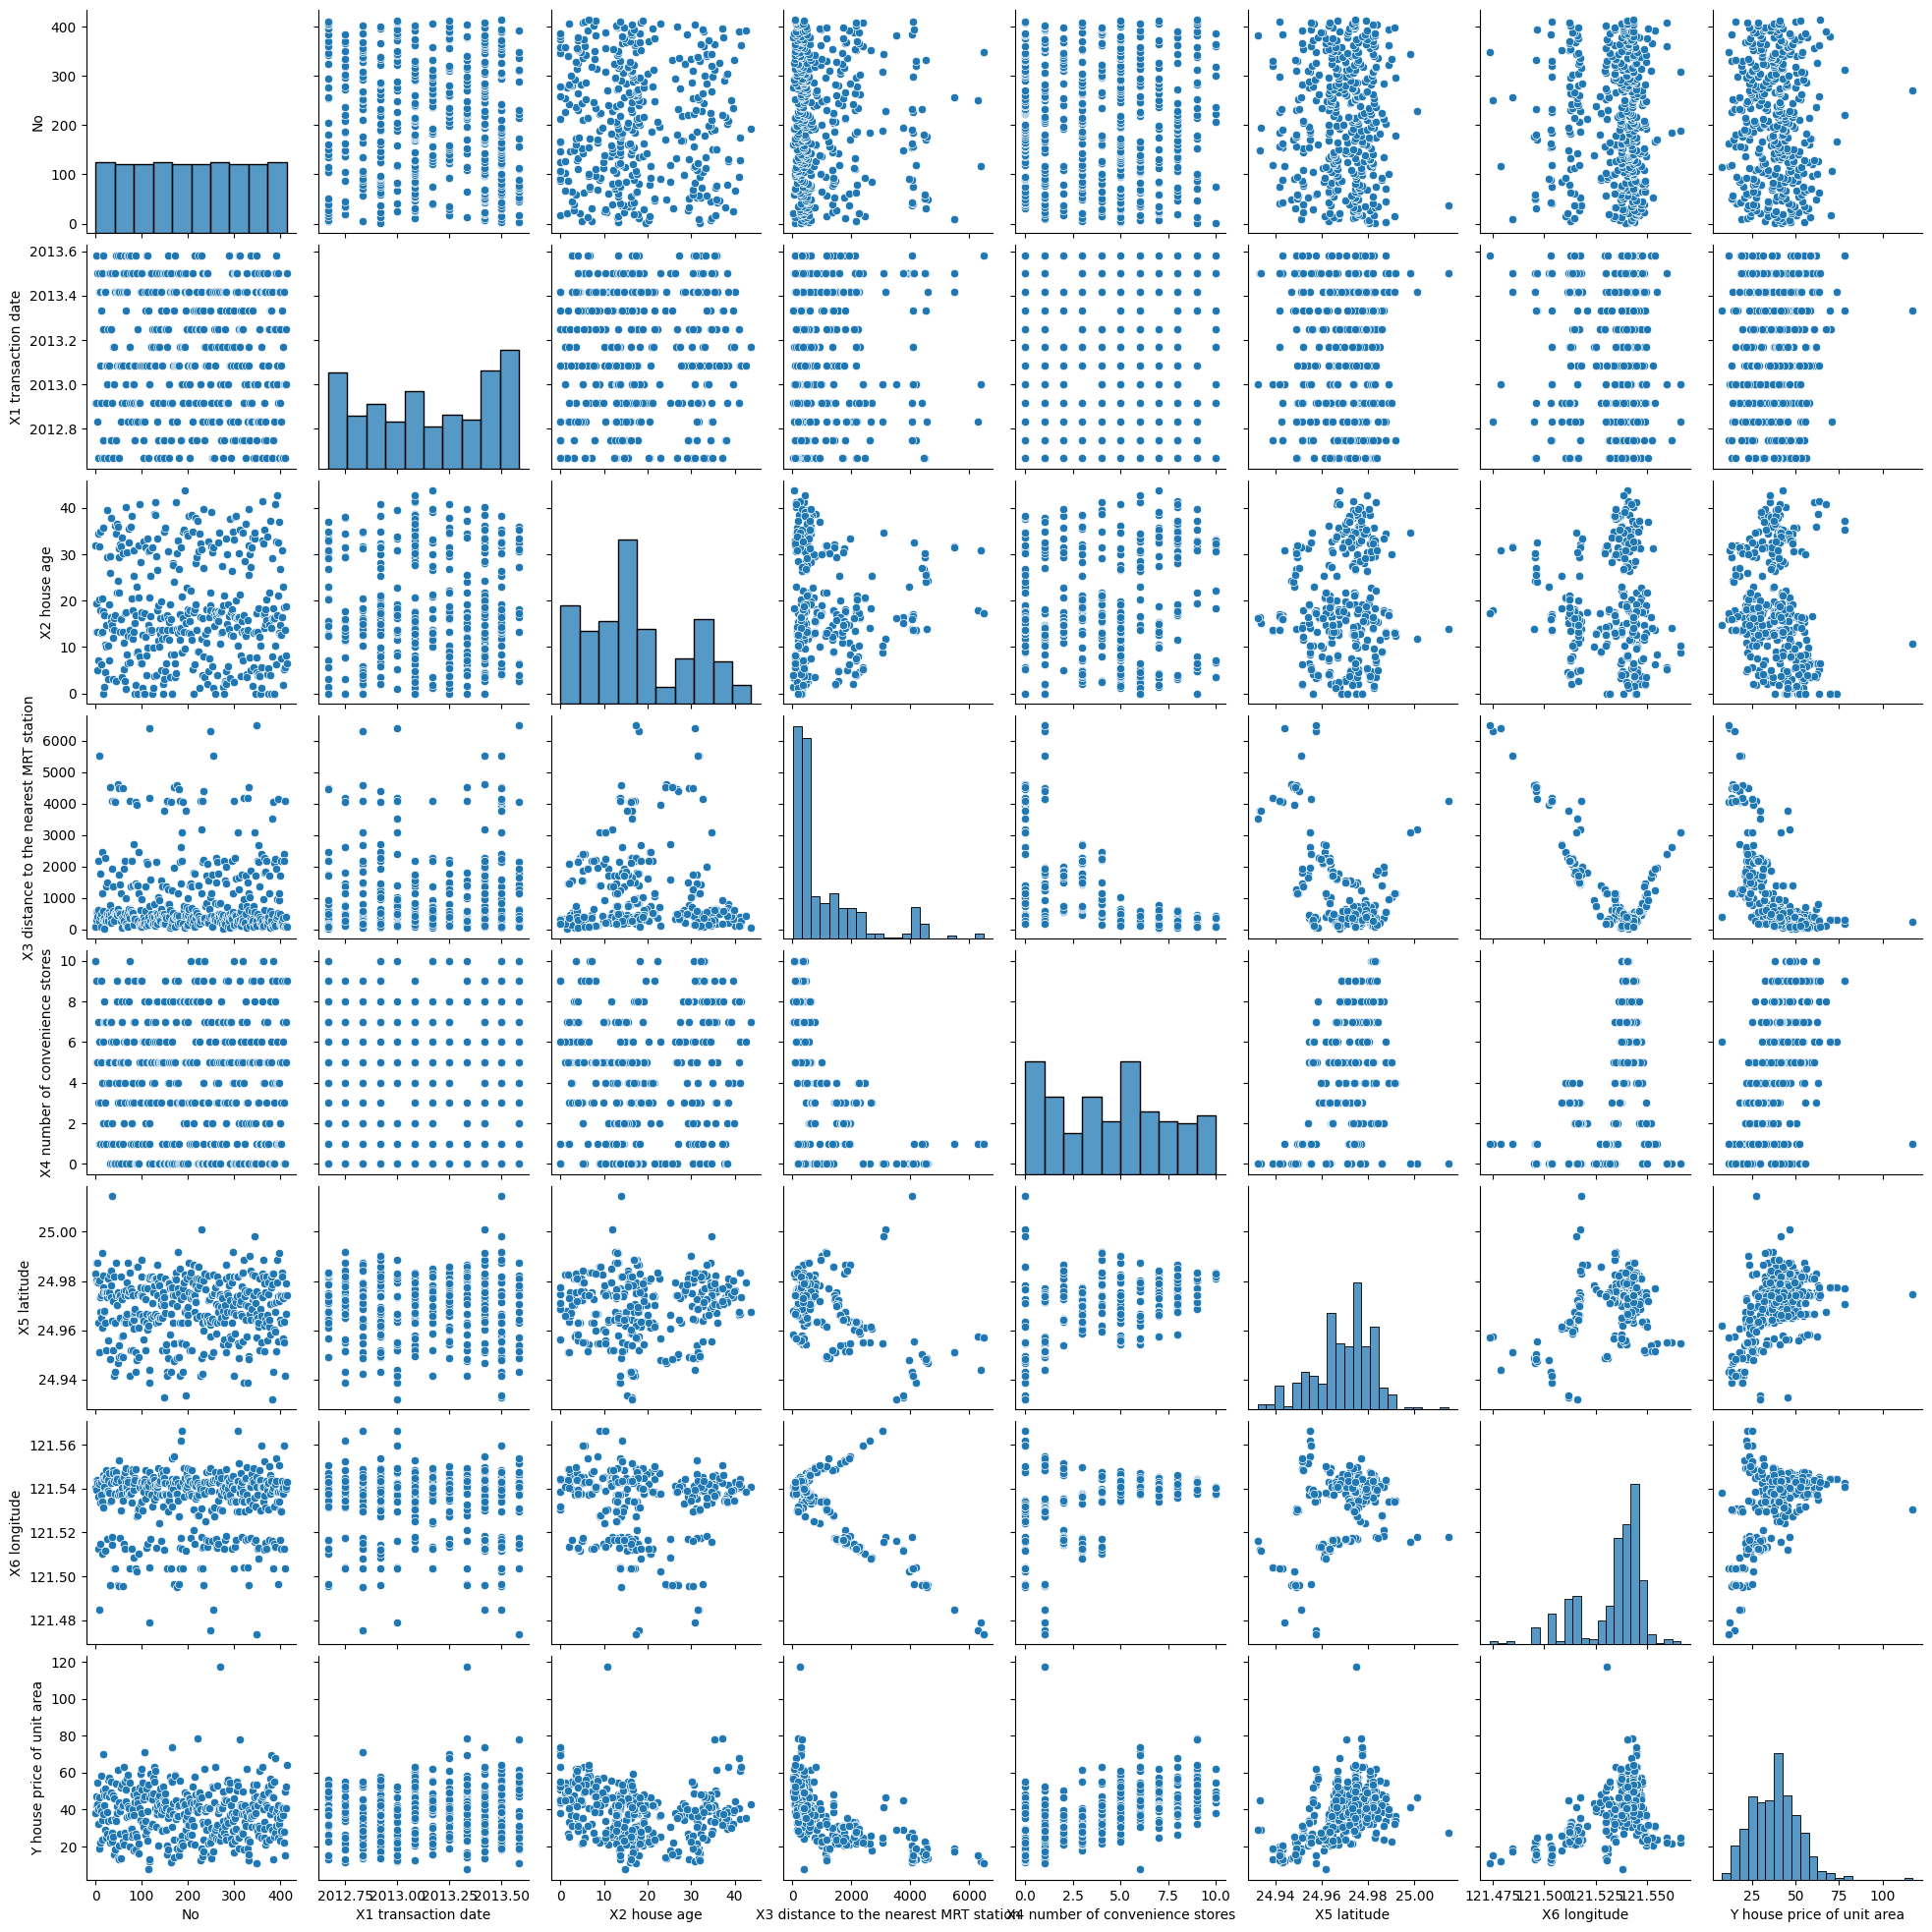

In [10]:
sns.pairplot(df)
plt.show()

4. Con base en la correlación y estas gráficas, ¿qué variables pueden modelarse con una regresión lineal?
Para la variable objtivo (precio de unidad de área)
house price of unit como variable objetivo y distancia al MRT más cerecano como varaible predictora (negativa muy leve)
house price of unit como variable objetivo y latitud como varaible predictora
house price of unit como variable objetivo y longitud como varaible predictora


### 📈 Entrenando un Modelo de Regresión Lineal

#### Arrays X y y

Vamos a quitar el precio por unidad de área.
La variable a predecir es el número de tiendas de convivencia cercanas

In [11]:
X=df.drop('Y house price of unit area', axis=1)

y=df['Y house price of unit area']

In [12]:
print("X=",X.shape,"\ny=", y.shape)

X= (414, 7) 
y= (414,)


### 🧱 División de los datos: Entrenamiento y Prueba

Ahora dividamos los datos en un conjunto de entrenamiento y un conjunto de prueba. Entrenaremos nuestro modelo en el conjunto de entrenamiento y luego usaremos el conjunto de prueba para evaluar el modelo.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [14]:
X_train.shape

(289, 7)

In [15]:
X_test.shape

(125, 7)

### Ahora vamos a usar la función predeterminada de Scikit-learn: LinearRegression()

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


####  Evaluación del modelo

In [18]:
model.coef_

array([-2.92429686e-03,  4.68668437e+00, -2.75675355e-01, -4.24850544e-03,
        1.17832502e+00,  2.40947692e+02,  1.86694591e+01])

In [19]:
pd.DataFrame(model.coef_, X.columns, columns=['Coeficientes'])

,Coeficientes
No,-0.002924
X1 transaction date,4.686684
X2 house age,-0.275675
X3 distance to the nearest MRT station,-0.004249
X4 number of convenience stores,1.178325
X5 latitude,240.947692
X6 longitude,18.669459


5. Regresa a la pregunta 4, y ve si los coeficientes corresponden la figura.
Los signos de los coeficientes coinciden con lo obervado en la matriz de dispersión de la pregunta 4. La antigüedad y distancia al metro presentan coeficientes de signo negativo conguentes con la caída de los precios en sus gráficas. Por otro lado las tiendas de convenciencia, la longtiud y la latitud (posición geográfica) muestran relaciones positivas acordes a la concentración de mayor valor en ciertas zonas urbanas, sin embargo el numero identificador es tan cercano a cero debido a su falta de correlación visual y lógica. 
6. ¿Cómo se interpreta cada coeficiente?
Cada coeficiente correspone, matemáticamente, a cada B_i lo que representa la razón de cambio de la variable objetivo por cada unidad de la variable predictora. Si es negativo, la relación entre las variables es inversamente proporcional, mientras que si es positivo es directamente proporcional. 

### Predicciones del modelo

In [20]:
y_pred = model.predict(X_test)

## ✔️ Métricas de Evaluación de Regresión

Aquí están las tres métricas de evaluación más comunes para problemas de regresión:

> - **Error Absoluto Medio (MAE)** es la media del valor absoluto de los errores:
> $$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

> - **Error Cuadrático Medio (MSE)** es la media de los errores al cuadrado:
> $$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

> - **Raíz del Error Cuadrático Medio (RMSE)** es la raíz cuadrada de la media de los errores al cuadrado:
> $$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

>  Comparando estas métricas:
> - **MAE** es la más fácil de entender, porque es el error promedio.
> - **MSE** es más popular que MAE, porque MSE "castiga" los errores más grandes, lo que tiende a ser útil en el mundo real.
> - **RMSE** es aún más popular que MSE, porque RMSE es interpretable en las unidades de "y".

> Todas estas son **funciones de pérdida**, porque queremos minimizarlas.

In [21]:
MAE= metrics.mean_absolute_error(y_test, y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RMSE= np.sqrt(MSE)

In [22]:
MAE

5.373024532570965

In [23]:
MSE

45.880307428741155

In [24]:
RMSE

np.float64(6.773500382279546)

## **Histograma de Residuos**

* **A menudo, para la Regresión Lineal, es una buena idea evaluar los residuos $$(y-\hat{y})$$ por separado y no solo calcular métricas de rendimiento (ej. RMSE).**

* **Exploremos por qué esto es importante...**

* **Los errores residuales deberían ser aleatorios y aproximarse a una distribución normal.**


<a href="https://uupload.ir/" target="_blank"><img src="https://s4.uupload.ir/files/2_pe68.png" border="0" alt="آپلود عکس" /></a>

In [25]:
test_residual= y_test - y_pred

In [26]:
pd.DataFrame({'Error Values': (test_residual)}).hvplot.kde()

:Distribution   [Error Values]   (Density)

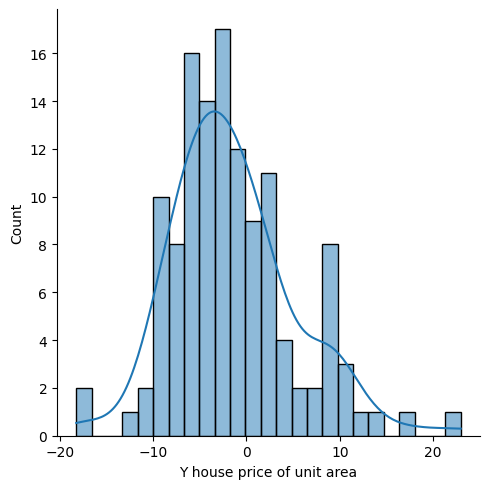

In [27]:
sns.displot(test_residual, bins=25, kde=True)
plt.show()

* **El gráfico de residuos muestra el error residual vs. el valor verdadero de y.**

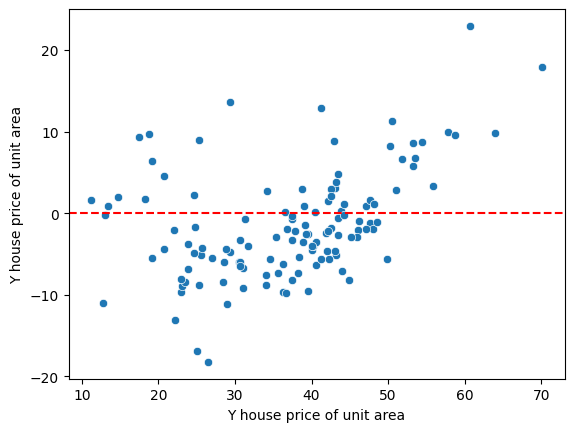

In [28]:
sns.scatterplot(x=y_test, y=test_residual)

plt.axhline(y=0, color='r', ls='--')
plt.show()